In [1]:
# -*- coding: utf-8 -*-
"""Bước 1: đọc bộ dữ liệu sinh viên và xem qua một lượt.

Chú thích trong tệp viết tiếng Việt có dấu, nhưng phần in ra màn hình cố ý
viết không dấu. Cửa sổ lệnh Windows thường không hiện được chữ có dấu.
"""

import pandas as pd

df = pd.read_csv("data/sinh_vien.csv")

print("Kich thuoc bang (so dong, so cot):", df.shape)
print()
print("Nam dong dau tien:")
print(df.head())
print()

# Cột qua_mon chỉ có hai giá trị, đếm số lần xuất hiện từng giá trị
print("So sinh vien theo ket qua:")
print(df["qua_mon"].value_counts())
print()
print("Ty le qua mon:", round(df["qua_mon"].mean(), 4))
print()

# So sánh số giờ ôn trung bình của hai nhóm
print("So gio on trung binh theo nhom:")
print(df.groupby("qua_mon")["gio_on"].mean().round(2))

Kich thuoc bang (so dong, so cot): (120, 3)

Nam dong dau tien:
   gio_on  diem_giua_ky  qua_mon
0     5.5           3.0        0
1    19.0           6.0        1
2    14.0           7.7        0
3    11.0           3.1        0
4    10.5           5.8        1

So sinh vien theo ket qua:
qua_mon
1    71
0    49
Name: count, dtype: int64

Ty le qua mon: 0.5917

So gio on trung binh theo nhom:
qua_mon
0     8.29
1    19.89
Name: gio_on, dtype: float64


In [3]:
# -*- coding: utf-8 -*-
"""Bước 2: làm quen hàm sigmoid bằng tay trước khi gọi thư viện."""

import numpy as np


def sigmoid(z):
  """Ep mot so thuc bat ky ve khoang tu 0 toi 1."""
  return 1 / (1 + np.exp(-z))


print("Bang gia tri cua ham sigmoid")
print(" z sigmoid(z)")
for z in [-6, -4, -2, -1, 0, 1, 2, 4, 6]:
  print(f"{z:3d} {sigmoid(z):.4f}")
print()

# Hai tính chất cần tự kiểm chứng
print("Kiem tra sigmoid(-z) = 1 - sigmoid(z):")
for z in [1.0, 2.5, 3.7]:
  trai = sigmoid(-z)
  phai = 1 - sigmoid(z)
  print(f" z = {z}: {trai:.6f} va {phai:.6f}")
print()

# Thử với một mô hình giả định w = 0.4 và b = -5
w, b = 0.4, -5.0
print(f"Mo hinh gia dinh: w = {w}, b = {b}")
print(" So gio on z = w*x + b Xac suat qua mon")
for gio in [5, 10, 12.5, 15, 20, 25]:
  z = w * gio + b
  print(f" {gio:5.1f} {z:6.2f} {sigmoid(z):.4f}")

Bang gia tri cua ham sigmoid
 z sigmoid(z)
 -6 0.0025
 -4 0.0180
 -2 0.1192
 -1 0.2689
  0 0.5000
  1 0.7311
  2 0.8808
  4 0.9820
  6 0.9975

Kiem tra sigmoid(-z) = 1 - sigmoid(z):
 z = 1.0: 0.268941 va 0.268941
 z = 2.5: 0.075858 va 0.075858
 z = 3.7: 0.024127 va 0.024127

Mo hinh gia dinh: w = 0.4, b = -5.0
 So gio on z = w*x + b Xac suat qua mon
   5.0  -3.00 0.0474
  10.0  -1.00 0.2689
  12.5   0.00 0.5000
  15.0   1.00 0.7311
  20.0   3.00 0.9526
  25.0   5.00 0.9933


In [5]:
# -*- coding: utf-8 -*-
"""Bước 3: để scikit-learn tìm w và b từ dữ liệu thật."""

import pandas as pd
from sklearn.linear_model import LogisticRegression

df = pd.read_csv("data/sinh_vien.csv")

# X phải là bảng hai chiều nên viết hai cặp ngoặc vuông.
# y là dãy một chiều nên chỉ một cặp.
X = df[["gio_on"]]
y = df["qua_mon"]

mo_hinh = LogisticRegression()
mo_hinh.fit(X, y)

w = float(mo_hinh.coef_[0][0])
b = float(mo_hinh.intercept_[0])

print(f"He so goc w = {w:.6f}")
print(f"He so chan b = {b:.6f}")
print()

# Số giờ ôn mà mô hình phân vân đúng năm mươi năm mươi
print(f"So gio on ung voi xac suat 0.5: {-b / w:.2f} gio")
print()

can_moi = pd.DataFrame({"gio_on": [5.0, 10.0, 13.0, 20.0, 28.0]})
xac_suat = mo_hinh.predict_proba(can_moi)[:, 1]
nhan = mo_hinh.predict(can_moi)

print("Du doan cho nam ban moi:")
print(" So gio on Xac suat qua Nhan mo hinh dua ra")
for gio, p, n in zip(can_moi["gio_on"], xac_suat, nhan):
  print(f" {gio:5.1f} {p:.4f} {n}")

He so goc w = 0.392819
He so chan b = -5.064890

So gio on ung voi xac suat 0.5: 12.89 gio

Du doan cho nam ban moi:
 So gio on Xac suat qua Nhan mo hinh dua ra
   5.0 0.0431 0
  10.0 0.2429 0
  13.0 0.5104 1
  20.0 0.9422 1
  28.0 0.9974 1


In [7]:
# -*- coding: utf-8 -*-
"""Bước 4: chia dữ liệu rồi chấm điểm mô hình bằng bốn thước đo."""

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                            precision_score, recall_score)
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

# stratify=y giữ đúng tỷ lệ qua và rớt ở cả hai phần sau khi chia
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)

print("So sinh vien de hoc :", len(X_train))
print("So sinh vien de kiem tra:", len(X_test))
print()

mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)

y_pred = mo_hinh.predict(X_test)

# Thứ tự bốn ô do scikit-learn quy định là TN, FP, FN, TP
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("Ma tran nham lan")
print(f" TN = {tn:2d} doan rot, that su rot")
print(f" FP = {fp:2d} doan qua, that ra rot")
print(f" FN = {fn:2d} doan rot, that ra qua")
print(f" TP = {tp:2d} doan qua, that su qua")
print()

print(f"Accuracy = {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision = {precision_score(y_test, y_pred):.4f}")
print(f"Recall = {recall_score(y_test, y_pred):.4f}")
print(f"F1 = {f1_score(y_test, y_pred):.4f}")
print()

# Tự tính lại bằng tay để đối chiếu với thư viện
print("Tu tinh lai bang cong thuc:")
n = len(y_test)
print(f" Accuracy = ({tp} + {tn}) / {n} = {(tp + tn) / n:.4f}")
print(f" Precision = {tp} / ({tp} + {fp}) = {tp / (tp + fp):.4f}")
print(f" Recall = {tp} / ({tp} + {fn}) = {tp / (tp + fn):.4f}")

So sinh vien de hoc : 90
So sinh vien de kiem tra: 30

Ma tran nham lan
 TN =  9 doan rot, that su rot
 FP =  3 doan qua, that ra rot
 FN =  1 doan rot, that ra qua
 TP = 17 doan qua, that su qua

Accuracy = 0.8667
Precision = 0.8500
Recall = 0.9444
F1 = 0.8947

Tu tinh lai bang cong thuc:
 Accuracy = (17 + 9) / 30 = 0.8667
 Precision = 17 / (17 + 3) = 0.8500
 Recall = 17 / (17 + 1) = 0.9444


In [9]:
# -*- coding: utf-8 -*-
"""Bước 5: tự áp ngưỡng và xem precision với recall đổi ra sao."""

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)

# predict_proba trả về hai cột, cột 0 cho lớp 0 và cột 1 cho lớp 1
p = mo_hinh.predict_proba(X_test)[:, 1]

print("Nguong So ban bi doan la qua Precision Recall")
for nguong in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
  y_pred = (p >= nguong).astype(int)
  pre = precision_score(y_test, y_pred, zero_division=1)
  rec = recall_score(y_test, y_pred, zero_division=0)
  print(f" {nguong:.1f} {y_pred.sum():3d}"
        f" {pre:.4f} {rec:.4f}")
print()

print("Doc bang tren tu duoi len:")
print(" Nguong cang cao thi mo hinh cang kho tinh,")
print(" precision tang nhung recall giam. Nguong thap thi nguoc lai.")

Nguong So ban bi doan la qua Precision Recall
 0.2  24 0.7500 1.0000
 0.3  20 0.8500 0.9444
 0.4  20 0.8500 0.9444
 0.5  20 0.8500 0.9444
 0.6  16 1.0000 0.8889
 0.7  15 1.0000 0.8333
 0.8  13 1.0000 0.7222

Doc bang tren tu duoi len:
 Nguong cang cao thi mo hinh cang kho tinh,
 precision tang nhung recall giam. Nguong thap thi nguoc lai.


In [11]:
# -*- coding: utf-8 -*-
"""Bước 6: thêm điểm giữa kỳ làm biến thứ hai."""

import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/sinh_vien.csv")
y = df["qua_mon"]

# Chỉ đổi đúng một chỗ: danh sách cột đưa vào X
for ten, cot in [("Mot bien", ["gio_on"]),
                 ("Hai bien", ["gio_on", "diem_giua_ky"])]:
  X = df[cot]
  X_train, X_test, y_train, y_test = train_test_split(
      X, y, test_size=0.25, random_state=17, stratify=y
  )
  mo_hinh = LogisticRegression().fit(X_train, y_train)
  do_chinh_xac = accuracy_score(y_test, mo_hinh.predict(X_test))
  print(f"{ten}: accuracy tren tap kiem tra = {do_chinh_xac:.4f}")
print()

# Xem kỹ hệ số của mô hình hai biến
X = df[["gio_on", "diem_giua_ky"]]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression().fit(X_train, y_train)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X.columns, mo_hinh.coef_[0]):
  print(f" {ten_cot:14s} {he_so:+.4f}")
print(f" {'he so chan':14s} {mo_hinh.intercept_[0]:+.4f}")
print()
print("Ca hai he so deu duong, nghia la on nhieu hon va")
print("diem giua ky cao hon deu lam tang xac suat qua mon.")

Mot bien: accuracy tren tap kiem tra = 0.8667
Hai bien: accuracy tren tap kiem tra = 0.9000

He so cua tung bien:
 gio_on         +0.3035
 diem_giua_ky   +0.5885
 he so chan     -6.9811

Ca hai he so deu duong, nghia la on nhieu hon va
diem giua ky cao hon deu lam tang xac suat qua mon.


In [13]:
import os
import shutil

# Nếu chưa có data/sinh_vien.csv thì tải lên, có rồi thì bỏ qua
os.makedirs("data", exist_ok=True)

if not os.path.exists("data/sinh_vien.csv"):
    print("Hay chon tep CSV sinh vien de tai len")
    da_tai = files.upload()
    ten_tep = list(da_tai.keys())[0]       # có thể là 1790676253354_sinh_vien.csv
    shutil.move(ten_tep, "data/sinh_vien.csv")

print("Thu muc hien tai:", os.getcwd())
print("Da co data/sinh_vien.csv:", os.path.exists("data/sinh_vien.csv"))

Thu muc hien tai: /content
Da co data/sinh_vien.csv: True


In [14]:
df = pd.read_csv("data/sinh_vien.csv")
X = df[["gio_on"]]
y = df["qua_mon"]

# Chia dữ liệu như mục 5: đổi một tham số là kết quả lệch tài liệu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=17, stratify=y
)
mo_hinh = LogisticRegression()
mo_hinh.fit(X_train, y_train)

print("Tong so sinh vien:", len(df))
print("De hoc:", len(X_train), "| De kiem tra:", len(X_test))

Tong so sinh vien: 120
De hoc: 90 | De kiem tra: 30


Bài tập 1

In [15]:
# Phép lọc theo điều kiện: pandas giữ lại các dòng thỏa điều kiện
nhom_cao = df[df["diem_giua_ky"] >= 7]
nhom_con_lai = df[df["diem_giua_ky"] < 7]

# Trung bình của cột 0/1 chính là tỷ lệ số 1, tức tỷ lệ qua môn
ty_le_nhom_cao = nhom_cao["qua_mon"].mean()
ty_le_nhom_con_lai = nhom_con_lai["qua_mon"].mean()

print("So ban co diem giua ky tu 7 tro len:", len(nhom_cao))
print("So ban con lai (diem giua ky < 7)  :", len(nhom_con_lai))
print()
print(f"Ty le qua mon nhom diem giua ky >= 7: {ty_le_nhom_cao:.4f}")
print(f"Ty le qua mon nhom con lai          : {ty_le_nhom_con_lai:.4f}")

So ban co diem giua ky tu 7 tro len: 31
So ban con lai (diem giua ky < 7)  : 89

Ty le qua mon nhom diem giua ky >= 7: 0.9032
Ty le qua mon nhom con lai          : 0.4831


Bài tập 2

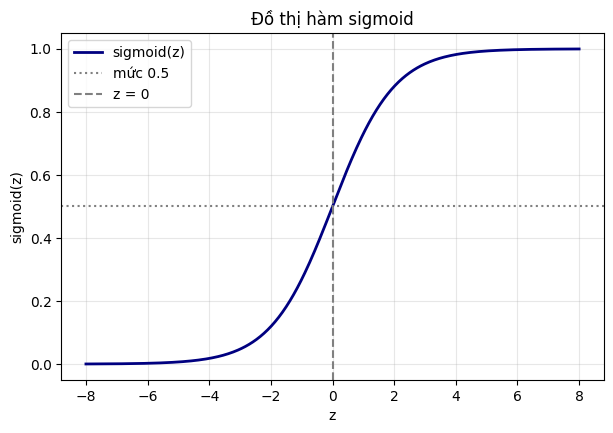

Da luu tep sigmoid.png
Kiem tra: sigmoid(0) = 0.5


In [17]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    """Ep mot so thuc bat ky ve khoang tu 0 toi 1."""
    return 1 / (1 + np.exp(-z))


z = np.linspace(-8, 8, 400)

plt.figure(figsize=(7, 4.5))
plt.plot(z, sigmoid(z), color="navy", linewidth=2, label="sigmoid(z)")
plt.axhline(0.5, color="gray", linestyle=":", label="mức 0.5")  # đường ngang
plt.axvline(0, color="gray", linestyle="--", label="z = 0")     # đường dọc
plt.title("Đồ thị hàm sigmoid")
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("sigmoid.png", dpi=150, bbox_inches="tight")
plt.show()

print("Da luu tep sigmoid.png")
print("Kiem tra: sigmoid(0) =", sigmoid(0))

Bài tập 3

In [18]:
# Khớp lại mô hình một biến trên toàn bộ 120 dòng, giống mục 4
mo_hinh_day_du = LogisticRegression().fit(X, y)
w = float(mo_hinh_day_du.coef_[0][0])
b = float(mo_hinh_day_du.intercept_[0])
print(f"w = {w:.6f}, b = {b:.6f}")
print(f"So gio on ung voi xac suat 0.5: -b/w = {-b / w:.4f} gio")
print()


def du_doan(gio):
    """In ra z, xac suat qua mon va nhan theo nguong 0.5."""
    z = w * gio + b                # bước 1: phần tuyến tính
    xac_suat = sigmoid(z)          # bước 2: bọc sigmoid
    nhan = 1 if xac_suat >= 0.5 else 0
    print(f" {gio:6.2f}  z = {z:8.4f}  xac suat = {xac_suat:.4f}  nhan = {nhan}")


print("Du doan cho tung ban:")
for gio in [3, 8, 12.89, 18, 26]:
    du_doan(gio)

# Đối chiếu với thư viện để chắc hàm tự viết đúng
p_thu_vien = mo_hinh_day_du.predict_proba(pd.DataFrame({"gio_on": [18.0]}))[0, 1]
print()
print(f"Doi chieu 18 gio: tu tinh {sigmoid(w * 18 + b):.4f}, thu vien {p_thu_vien:.4f}")

w = 0.392819, b = -5.064890
So gio on ung voi xac suat 0.5: -b/w = 12.8937 gio

Du doan cho tung ban:
   3.00  z =  -3.8864  xac suat = 0.0201  nhan = 0
   8.00  z =  -1.9223  xac suat = 0.1276  nhan = 0
  12.89  z =  -0.0015  xac suat = 0.4996  nhan = 0
  18.00  z =   2.0059  xac suat = 0.8814  nhan = 1
  26.00  z =   5.1484  xac suat = 0.9942  nhan = 1

Doi chieu 18 gio: tu tinh 0.8814, thu vien 0.8814


Bài tập 4

In [19]:
y_pred = mo_hinh.predict(X_test)

# Thứ tự bốn ô do scikit-learn quy định là TN, FP, FN, TP
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print("Ma tran nham lan")
print(f"  TN = {tn:2d}  doan rot, that su rot")
print(f"  FP = {fp:2d}  doan qua, that ra rot")
print(f"  FN = {fn:2d}  doan rot, that ra qua")
print(f"  TP = {tp:2d}  doan qua, that su qua")
print()

# Tự tính bốn thước đo, chỉ dùng bốn số ở trên
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp)
recall = tp / (tp + fn)
f1 = 2 * precision * recall / (precision + recall)

print("Tu tinh bang cong thuc:")
print(f"  Accuracy  = ({tp} + {tn}) / {tp + tn + fp + fn} = {accuracy:.4f}")
print(f"  Precision = {tp} / ({tp} + {fp}) = {precision:.4f}")
print(f"  Recall    = {tp} / ({tp} + {fn}) = {recall:.4f}")
print(f"  F1        = 2 * {precision:.4f} * {recall:.4f} / ({precision:.4f} + {recall:.4f}) = {f1:.4f}")
print()

# Đối chiếu với con số thư viện đã in trong tài liệu (mục 5)
tai_lieu = {"Accuracy": 0.8667, "Precision": 0.8500, "Recall": 0.9444, "F1": 0.8947}
tu_tinh = {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1": f1}
print("Doi chieu voi tai lieu:")
for ten in tai_lieu:
    khop = round(tu_tinh[ten], 4) == tai_lieu[ten]
    print(f"  {ten:9s} tu tinh {tu_tinh[ten]:.4f} | tai lieu {tai_lieu[ten]:.4f} | {'KHOP' if khop else 'LECH'}")

Ma tran nham lan
  TN =  9  doan rot, that su rot
  FP =  3  doan qua, that ra rot
  FN =  1  doan rot, that ra qua
  TP = 17  doan qua, that su qua

Tu tinh bang cong thuc:
  Accuracy  = (17 + 9) / 30 = 0.8667
  Precision = 17 / (17 + 3) = 0.8500
  Recall    = 17 / (17 + 1) = 0.9444
  F1        = 2 * 0.8500 * 0.9444 / (0.8500 + 0.9444) = 0.8947

Doi chieu voi tai lieu:
  Accuracy  tu tinh 0.8667 | tai lieu 0.8667 | KHOP
  Precision tu tinh 0.8500 | tai lieu 0.8500 | KHOP
  Recall    tu tinh 0.9444 | tai lieu 0.9444 | KHOP
  F1        tu tinh 0.8947 | tai lieu 0.8947 | KHOP


Bài tập 5

In [20]:
p = mo_hinh.predict_proba(X_test)[:, 1]

# round để tránh số lẻ kiểu 0.15000000000000002 do np.arange
cac_nguong = np.round(np.arange(0.05, 1.0, 0.05), 2)

print("Nguong  So ban bi doan la qua  F1")
cac_f1 = []
for nguong in cac_nguong:
    y_theo_nguong = (p >= nguong).astype(int)
    f1 = f1_score(y_test, y_theo_nguong, zero_division=0)
    cac_f1.append(f1)
    print(f"  {nguong:.2f}  {y_theo_nguong.sum():15d}  {f1:.4f}")
print()

f1_cao_nhat = max(cac_f1)
nguong_tot = [float(t) for t, f in zip(cac_nguong, cac_f1) if f == f1_cao_nhat]

print(f"F1 cao nhat = {f1_cao_nhat:.4f}")
print("Cac nguong cho F1 cao nhat:", nguong_tot)
print("Nguong tot nhat (nho nhat trong cac nguong do):", nguong_tot[0])
print("Nguong mac dinh 0.5 co nam trong danh sach do khong?", 0.5 in nguong_tot)

Nguong  So ban bi doan la qua  F1
  0.05               28  0.7826
  0.10               26  0.8182
  0.15               26  0.8182
  0.20               24  0.8571
  0.25               22  0.9000
  0.30               20  0.8947
  0.35               20  0.8947
  0.40               20  0.8947
  0.45               20  0.8947
  0.50               20  0.8947
  0.55               18  0.8889
  0.60               16  0.9412
  0.65               16  0.9412
  0.70               15  0.9091
  0.75               14  0.8750
  0.80               13  0.8387
  0.85               12  0.8000
  0.90                7  0.5600
  0.95                5  0.4348

F1 cao nhat = 0.9412
Cac nguong cho F1 cao nhat: [0.6, 0.65]
Nguong tot nhat (nho nhat trong cac nguong do): 0.6
Nguong mac dinh 0.5 co nam trong danh sach do khong? False


Bài tập 6

In [21]:
y_pred = mo_hinh.predict(X_test)

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print(f"TN = {tn}, FP = {fp}, FN = {fn}, TP = {tp}")
print()

pre_qua = precision_score(y_test, y_pred, pos_label=1)
rec_qua = recall_score(y_test, y_pred, pos_label=1)
pre_rot = precision_score(y_test, y_pred, pos_label=0)
rec_rot = recall_score(y_test, y_pred, pos_label=0)

print("Lop duong = QUA MON (lop 1):")
print(f"  Precision = {pre_qua:.4f}   Recall = {rec_qua:.4f}")
print("Lop duong = ROT MON (lop 0):")
print(f"  Precision = {pre_rot:.4f}   Recall = {rec_rot:.4f}")
print()

# Tự kiểm bằng công thức: khi lớp dương là lớp 0 thì vai trò các ô đổi chỗ
print("Tu kiem lop 0 bang cong thuc:")
print(f"  Precision = TN / (TN + FN) = {tn} / ({tn} + {fn}) = {tn / (tn + fn):.4f}")
print(f"  Recall    = TN / (TN + FP) = {tn} / ({tn} + {fp}) = {tn / (tn + fp):.4f}")

TN = 9, FP = 3, FN = 1, TP = 17

Lop duong = QUA MON (lop 1):
  Precision = 0.8500   Recall = 0.9444
Lop duong = ROT MON (lop 0):
  Precision = 0.9000   Recall = 0.7500

Tu kiem lop 0 bang cong thuc:
  Precision = TN / (TN + FN) = 9 / (9 + 1) = 0.9000
  Recall    = TN / (TN + FP) = 9 / (9 + 3) = 0.7500
